#**SENTIMENT ANALYSIS FOR NOTION APP**

##**1. Install Library**

In [ ]:
!pip install tqdm

In [ ]:
# Import Dataset
import requests
from io import StringIO
import csv

# Pre-processing data
import re  # Modul untuk bekerja dengan ekspresi reguler
import string
import nltk  # Natural Language Toolkit
from nltk.tokenize import word_tokenize  # Tokenizing text
from nltk.corpus import stopwords  # Stopwords list
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from functools import lru_cache
from sklearn.preprocessing import LabelEncoder

#Ekstraksi fitur
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack, csr_matrix
from sentence_transformers import SentenceTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Train Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)

#Train Deep Learning
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

#Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

In [ ]:
nltk.download('punkt')  # Tokenizing dataset
nltk.download('stopwords')  # Stopwords dataset
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

## **2. Preprocessing Data**

##Data Loading

In [ ]:
df_notion = pd.read_csv('clean_data.csv')
df_notion.head()

,content,score,thumbsUpCount
0,This was a fantastic app and superior alternat...,1,282
1,This app is great for organization and just wh...,4,5
2,This app has become my second brain and awesom...,5,2
3,The app version is horrible. I love using Noti...,3,0
4,The many free templates are a godsend. I use A...,5,31


### Preprocessing Function

In [ ]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # Remove mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # Remove hashtag
    text = re.sub(r'RT[\s]', '', text) # Remove RT
    text = re.sub(r"http\S+", '', text) # Remove link
    text = re.sub(r'[0-9]+', '', text) # Remove numbers
    text = re.sub(r'[^A-Za-z!? ]', '', text) # Remove characters other than number, ?!, and alphabet

    text = text.replace('\n', ' ') # Replace enter with space
    text = text.translate(str.maketrans('', '', string.punctuation)) # Erase all punctuation
    text = text.strip(' ') # Erase strip before and after sentence
    return text

def casefoldingText(text): # Casefolding
    text = text.lower()
    return text

slangwords = {
    # Common abbreviation
    "cant": "can not",
    "wasnt": "was not",
    "doesnt": "does not",
    "ive": "i have",
    "wont": "will not",
    "isnt": "is not",
    "arent": "are not",
    "havent": "have not",
    "hadnt": "had not",
    "couldnt": "could not",
    "shouldnt": "should not",
    "wouldnt": "would not",
    "didnt": "did not",
    "thats": "that is",
    "im": "i am",
    "youre": "you are",
    "hes": "he is",
    "shes": "she is",
    "its": "it is",
    "theyre": "they are",
    "weve": "we have",

    # Popular slang
    "asap": "as soon as possible",
    "app": "application",
    "btw": "by the way",
    "omg": "oh my god",
    "lol": "laughing out loud",
    "idk": "i dont know",
    "imo": "in my opinion",
    "fyi": "for your information",
    "aka": "also known as",
    "brb": "be right back",
    "tbh": "to be honest",
    "ikr": "i know right",
    "tmi": "too much information",
    "gr8": "great",
    "b4": "before",
    "buggy": "flawed",
    "cuz": "because",
    "luv": "love",
    "thx": "thanks",
    "pls": "please",
    "ur": "your",
    "tho": "though"
}

def fix_slangwords(text): # Replace slang word
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

def tokenizingText(text): # Split string into token
    text = word_tokenize(text)
    return text

def filteringText(text): # Remove stopwords
    listStopwords = set(stopwords.words('english'))
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

negative_words = {
    "bad": "good", "terrible": "great", "awful": "amazing", "horrible": "wonderful",
    "worst": "best", "poor": "excellent", "sad": "happy", "ugly": "beautiful",
    "hate": "love", "angry": "calm", "slow": "fast", "hard": "easy",
    "broken": "working", "buggy": "stable", "difficult": "simple", "boring": "fun",
    "disappointing": "satisfying", "annoying": "pleasant", "stupid": "smart",
    "worse": "better", "dirty": "clean", "low": "high", "negative": "positive",
    "cheap": "premium", "weak": "strong", "fake": "real", "lazy": "active",
    "fail": "succeed", "messy": "organized", "useless": "useful", "noisy": "quiet",
    "cold": "warm", "tired": "energetic", "uglier": "prettier", "hateful": "kind",
    "incomplete": "complete", "unfair": "fair", "unfriendly": "friendly",
    "unreliable": "reliable", "unhappy": "happy", "unpleasant": "pleasant",
    "uninteresting": "interesting", "unsuccessful": "successful"
}

def handle_negations(tokens): # Negation handling (example: not bad = good)
    new_tokens = []
    skip = False
    for i, word in enumerate(tokens):
        if skip:
            skip = False
            continue

        if word == "not" and i + 1 < len(tokens):
            next_word = tokens[i + 1]

            if next_word in negative_words:
                new_tokens.append(negative_words[next_word])
                skip = True
            else:
                new_tokens.append("not")
        else:
            new_tokens.append(word)
    return new_tokens

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag): # Convert Part-of-Speech (POS) tag into format required by WordNet
    tag = tag[0].upper()
    tag_dict = {
        'J': wordnet.ADJ,
        'N': wordnet.NOUN,
        'V': wordnet.VERB,
        'R': wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

@lru_cache(maxsize=100000)
def lemmatize_cached(word): # Save lemmatized word to cache to avoid lemmatization for the same word
    """Lemmatize satu kata, disimpan di cache"""
    return lemmatizer.lemmatize(word, get_wordnet_pos(word))

def lemmatize_tokens(tokens): # Lemmatize tokens using POS for better accuracy
    pos_tags = nltk.pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags]


### Data Preprocessing

In [ ]:
tqdm.pandas() # Progress bar

print('Cleaning Text is running...')
df_notion['text_clean'] = df_notion['content'].progress_apply(cleaningText)

print('Casefolding Text is running...')
df_notion['text_casefoldingText'] = df_notion['text_clean'].progress_apply(casefoldingText)

print('Fixing Slangwords is running...')
df_notion['text_slangwords'] = df_notion['text_casefoldingText'].progress_apply(fix_slangwords)

print('Tokenizing Text is running...')
df_notion['text_tokenizingText'] = df_notion['text_slangwords'].progress_apply(tokenizingText)

print('Filtering Text is running...')
df_notion['text_stopword'] = df_notion['text_tokenizingText'].progress_apply(filteringText)

print('Handling Negations is running...')
df_notion['negationHandling_text'] = df_notion['text_stopword'].progress_apply(handle_negations)

print('Lemmatizing Text is running...')
df_notion['final_text'] = df_notion['negationHandling_text'].progress_apply(lambda tokens: ' '.join(lemmatize_tokens(tokens)))

Cleaning Text is running...


100%|██████████| 15000/15000 [00:00<00:00, 55328.86it/s]


Casefolding Text is running...


100%|██████████| 15000/15000 [00:00<00:00, 882342.65it/s]


Fixing Slangwords is running...


...

100%|██████████| 15000/15000 [00:01<00:00, 10810.85it/s]


Handling Negations is running...


100%|██████████| 15000/15000 [00:00<00:00, 332794.99it/s]


Lemmatizing Text is running...


100%|██████████| 15000/15000 [00:19<00:00, 787.39it/s] 


In [ ]:
df_notion.head()

,content,score,thumbsUpCount,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,negationHandling_text,final_text
0,This was a fantastic app and superior alternat...,1,282,This was a fantastic app and superior alternat...,this was a fantastic app and superior alternat...,this was a fantastic application and superior ...,"[this, was, a, fantastic, application, and, su...","[fantastic, application, superior, alternative...","[fantastic, application, superior, alternative...",fantastic application superior alternative wri...
1,This app is great for organization and just wh...,4,5,This app is great for organization and just wh...,this app is great for organization and just wh...,this application is great for organization and...,"[this, application, is, great, for, organizati...","[application, great, organization, whatever, n...","[application, great, organization, whatever, n...",application great organization whatever need w...
2,This app has become my second brain and awesom...,5,2,This app has become my second brain and awesom...,this app has become my second brain and awesom...,this application has become my second brain an...,"[this, application, has, become, my, second, b...","[application, become, second, brain, awesome, ...","[application, become, second, brain, awesome, ...",application become second brain awesome assist...
3,The app version is horrible. I love using Noti...,3,0,The app version is horrible I love using Notio...,the app version is horrible i love using notio...,the application version is horrible i love usi...,"[the, application, version, is, horrible, i, l...","[application, version, horrible, love, using, ...","[application, version, horrible, love, using, ...",application version horrible love use notion p...
4,The many free templates are a godsend. I use A...,5,31,The many free templates are a godsend I use As...,the many free templates are a godsend i use as...,the many free templates are a godsend i use as...,"[the, many, free, templates, are, a, godsend, ...","[many, free, templates, godsend, use, assignme...","[many, free, templates, godsend, use, assignme...",many free template godsend use assignment trac...


##**3. LABELLING DATA (POSITIVE, NEUTRAL, NEGATIVE)**

### Load Lexicon Dataset

In [ ]:
# URL
URL_POSITIVE = 'https://raw.githubusercontent.com/jeffreybreen/twitter-sentiment-analysis-tutorial-201107/master/data/opinion-lexicon-English/positive-words.txt'
URL_NEGATIVE = 'https://raw.githubusercontent.com/jeffreybreen/twitter-sentiment-analysis-tutorial-201107/master/data/opinion-lexicon-English/negative-words.txt'

# Give +1 score for positive words
lexicon_positive = dict()
response = requests.get(URL_POSITIVE)

if response.status_code == 200:
    for word in response.text.splitlines():
        word = word.strip()
        if word and not word.startswith(';'):
            lexicon_positive[word] = 1 # Asumsi skor +1
else:
    print("Failed to fetch positive lexicon data")


# Give -1 score for negative words
lexicon_negative = dict()
response = requests.get(URL_NEGATIVE)

if response.status_code == 200:
    for word in response.text.splitlines():
        word = word.strip()
        if word and not word.startswith(';'):
            lexicon_negative[word] = -1
else:
    print("Failed to fetch negative lexicon data")

print(f"Jumlah kata positif: {len(lexicon_positive)}")
print(f"Jumlah kata negatif: {len(lexicon_negative)}")

Jumlah kata positif: 2006
Jumlah kata negatif: 4783


### Get Lexicon Score

In [ ]:
def sentiment_analysis_lexicon(text):
    score = 0
    for word in text:
        if word in lexicon_positive:
            score += 1
        elif word in lexicon_negative:
            score -= 1
    if len(text) > 0:
        score /= len(text)
    return score

df_notion['score'] = df_notion['text_stopword'].apply(sentiment_analysis_lexicon)

# Data threshold
mean_score = df_notion['score'].mean()
std_score = df_notion['score'].std()
neg_thresh = mean_score - std_score*0.5
pos_thresh = mean_score + std_score*0.5

### Labelling Data

In [ ]:
def get_sentiment_label(score):
    if score > pos_thresh:
        return 'positive'
    elif score < neg_thresh:
        return 'negative'
    else:
        return 'neutral'

df_notion['label'] = df_notion['score'].apply(get_sentiment_label)

print(df_notion['label'].value_counts())

label
neutral     7914
positive    3984
negative    3102
Name: count, dtype: int64


### Data Splitting

In [ ]:
X = df_notion[['final_text', 'thumbsUpCount', 'score']]
y = df_notion['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

##**4. Features Extraction**

In [ ]:
# TF-IDF: Using Numerical Vector
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=3, max_df=0.9)
X_train_tfidf = tfidf.fit_transform(X_train['final_text'])
X_test_tfidf = tfidf.transform(X_test['final_text'])

# CountVectorizer: using word frequencies
count_vect = CountVectorizer(max_features=3000, ngram_range=(1,2), min_df=3, max_df=0.9)
X_train_count = count_vect.fit_transform(X_train['final_text'])
X_test_count = count_vect.transform(X_test['final_text'])

# SentenceTransformer: Using trasnformer model to get semantic representation
embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_train_emb = embedder.encode(X_train['final_text'].tolist())
X_test_emb = embedder.encode(X_test['final_text'].tolist())

# Convert Embedding result to sparse
X_train_emb_sparse = csr_matrix(X_train_emb)
X_test_emb_sparse = csr_matrix(X_test_emb)

# Get numeric features (thumbsUpCount and score)
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[['thumbsUpCount', 'score']])
X_test_num = scaler.transform(X_test[['thumbsUpCount', 'score']])

X_train_num_sparse = csr_matrix(X_train_num)
X_test_num_sparse = csr_matrix(X_test_num)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

###TF-IDF, Embedding, and Numeric Value

In [ ]:
X_train_tfidf = hstack([X_train_tfidf, X_train_emb_sparse, X_train_num_sparse])
X_test_tfidf = hstack([X_test_tfidf, X_test_emb_sparse, X_test_num_sparse])

print("✅ Shape hasil preprocessing dengan TF-IDF:")
print("Train:", X_train_tfidf.shape)
print("Test :", X_test_tfidf.shape)

✅ Shape hasil preprocessing dengan TF-IDF:
Train: (12750, 3386)
Test : (2250, 3386)


###Count, Embedding, and Numeric Value

In [ ]:
X_train_count = hstack([X_train_count, X_train_emb_sparse, X_train_num_sparse])
X_test_count = hstack([X_test_count, X_test_emb_sparse, X_test_num_sparse])

print("✅ Shape hasil preprocessing dengan Count:")
print("Train:", X_train_count.shape)
print("Test :", X_test_count.shape)

✅ Shape hasil preprocessing dengan Count:
Train: (12750, 3386)
Test : (2250, 3386)


##**5. MACHINE LEARNING MODELS**

### Support Vector Machine (SVM)

In [ ]:
svm = LinearSVC(random_state=42, C=0.5, class_weight='balanced')

# TF-IDF
svm.fit(X_train_tfidf, y_train)
y_tfidf_train_svm = svm.predict(X_train_tfidf)
y_tfidf_test_svm = svm.predict(X_test_tfidf)

# Count
svm.fit(X_train_count, y_train)
y_count_train_svm = svm.predict(X_train_count)
y_count_test_svm = svm.predict(X_test_count)

### Logistic Regression

In [ ]:
logreg = LogisticRegression(random_state=42, C=0.5, solver='liblinear', class_weight='balanced')

# TF-IDF
logreg.fit(X_train_tfidf, y_train)
y_tfidf_train_logreg = logreg.predict(X_train_tfidf)
y_tfidf_test_logreg = logreg.predict(X_test_tfidf)

# Count
logreg.fit(X_train_count, y_train)
y_count_train_logreg = logreg.predict(X_train_count)
y_count_test_logreg = logreg.predict(X_test_count)

### Model Evaluation


📌 Model Evaluation: Support Vector Machine (TF-IDF)
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

    negative      0.972     0.978     0.975       465
     neutral      0.985     0.973     0.979      1187
    positive      0.969     0.988     0.978       598

    accuracy                          0.978      2250
   macro avg      0.976     0.980     0.978      2250
weighted avg      0.978     0.978     0.978      2250

F1 Score (Macro): 0.978
F1 Score (Weighted): 0.978
Precision (Macro): 0.976
Recall (Macro): 0.980


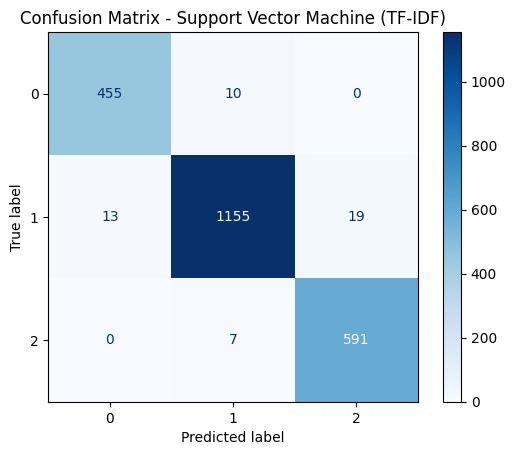


📌 Model Evaluation: Logistic Regression(TF-IDF)
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

    negative      0.993     0.974     0.984       465
     neutral      0.981     0.981     0.981      1187
    positive      0.967     0.982     0.974       598

    accuracy                          0.980      2250
   macro avg      0.980     0.979     0.980      2250
weighted avg      0.980     0.980     0.980      2250

F1 Score (Macro): 0.980
F1 Score (Weighted): 0.980
Precision (Macro): 0.980
Recall (Macro): 0.979


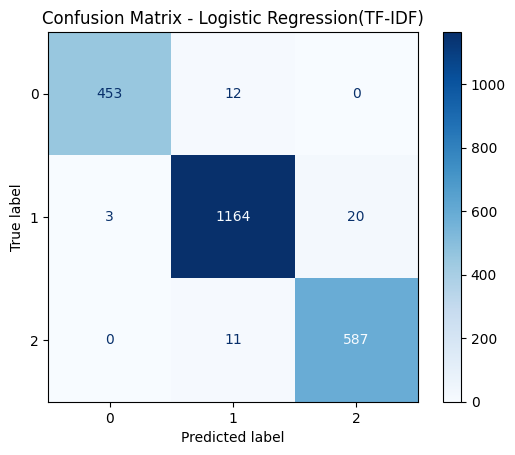


📌 Model Evaluation: Support Vector Machine (Count)
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

    negative      0.921     0.908     0.914       465
     neutral      0.936     0.944     0.940      1187
    positive      0.948     0.945     0.946       598

    accuracy                          0.936      2250
   macro avg      0.935     0.932     0.934      2250
weighted avg      0.936     0.936     0.936      2250

F1 Score (Macro): 0.934
F1 Score (Weighted): 0.936
Precision (Macro): 0.935
Recall (Macro): 0.932


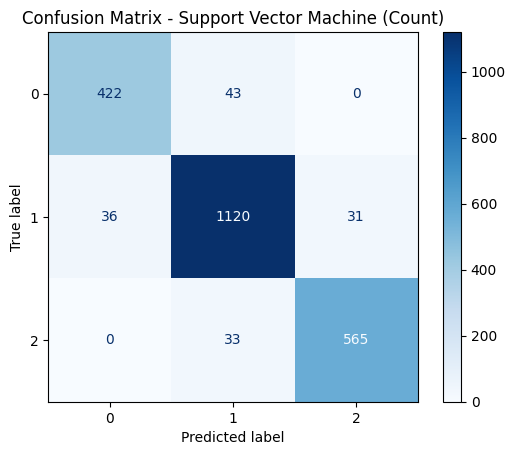


📌 Model Evaluation: Logistic Regression (Count)
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

    negative      0.964     0.923     0.943       465
     neutral      0.948     0.960     0.954      1187
    positive      0.947     0.955     0.951       598

    accuracy                          0.951      2250
   macro avg      0.953     0.946     0.949      2250
weighted avg      0.951     0.951     0.951      2250

F1 Score (Macro): 0.949
F1 Score (Weighted): 0.951
Precision (Macro): 0.953
Recall (Macro): 0.946


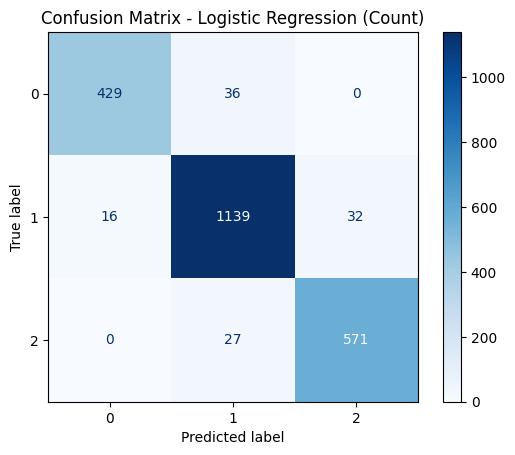

In [ ]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n📌 Model Evaluation: {name}")
    print("-" * 40)
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=3))

    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')

    print(f"F1 Score (Macro): {f1_macro:.3f}")
    print(f"F1 Score (Weighted): {f1_weighted:.3f}")
    print(f"Precision (Macro): {precision:.3f}")
    print(f"Recall (Macro): {recall:.3f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

evaluate_model("Support Vector Machine (TF-IDF)", y_test, y_tfidf_test_svm)
evaluate_model("Logistic Regression(TF-IDF)", y_test, y_tfidf_test_logreg)
evaluate_model("Support Vector Machine (Count)", y_test, y_count_test_svm)
evaluate_model("Logistic Regression (Count)", y_test, y_count_test_logreg)

##**6. Deep Learning Model using Multi Layer Perceptron**

### Data Training

In [ ]:
# Convert TF-IDF to dense array Float32
X_train_dense = X_train_tfidf.toarray().astype(np.float32)
X_test_dense = X_test_tfidf.toarray().astype(np.float32)

# Encode categorical label
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Convert encoded label to int32
y_train_enc = np.array(y_train_enc, dtype=np.int32)
y_test_enc = np.array(y_test_enc, dtype=np.int32)

# MLP model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(
    X_train_dense,
    y_train_enc,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_dense, y_test_enc)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8838 - loss: 0.2821 - val_accuracy: 0.9716 - val_loss: 0.0898
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9787 - loss: 0.0640 - val_accuracy: 0.9631 - val_loss: 0.0936
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9898 - loss: 0.0318 - val_accuracy: 0.9582 - val_loss: 0.0931
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9946 - loss: 0.0168 - val_accuracy: 0.9676 - val_loss: 0.0899
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9968 - loss: 0.0108 - val_accuracy: 0.9658 - val_loss: 0.1050
Epoch 6/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9991 - loss: 0.0052 - val_accuracy: 0.9676 - val_loss: 0.0941
Epoch 7/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9980 - loss: 0.0056 - val_accuracy: 0.9636 - val_loss: 0.1225
Epoch 8/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9982 - loss: 0.0064 - val_accuracy: 0.

### Model Evaluation

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

📌 Model Evaluation: Multi Layer Perceptron
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0      0.970     0.974     0.972       463
           1      0.962     0.969     0.966      1178
           2      0.963     0.946     0.954       609

    accuracy                          0.964      2250
   macro avg      0.965     0.963     0.964      2250
weighted avg      0.964     0.964     0.964      2250

F1 Score (Macro): 0.964
F1 Score (Weighted): 0.964
Precision (Macro): 0.965
Recall (Macro): 0.963


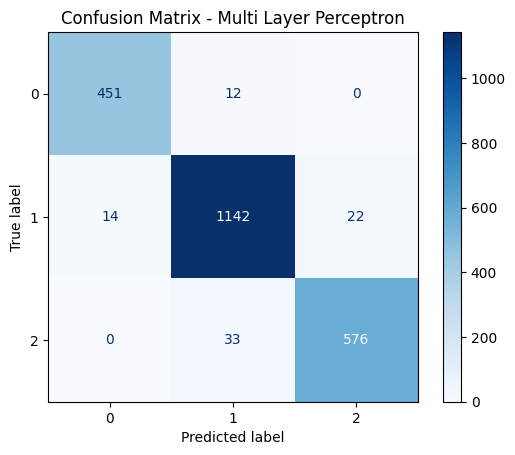

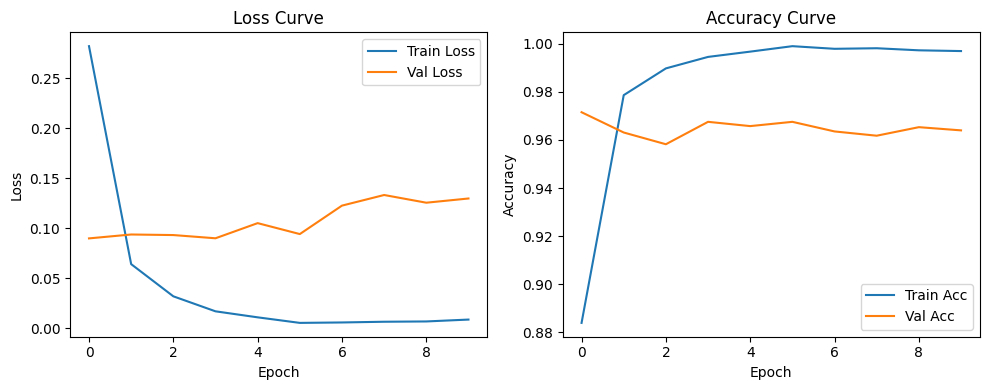

In [ ]:
# Loss and accuracy
test_loss, test_acc = model.evaluate(X_test_dense, y_test_enc, verbose=0)

y_pred_probs = model.predict(X_test_dense)
y_pred = np.argmax(y_pred_probs, axis=1)

# Model evaluation
evaluate_model("Multi Layer Perceptron", y_pred, y_test_enc)
print('\n')

# Training plot history
history_data = model.history.history

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_data['loss'], label='Train Loss')
plt.plot(history_data['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_data['accuracy'], label='Train Acc')
plt.plot(history_data['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## **GET REQUIREMENTS.TXT**

In [ ]:
pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.52.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.9.0.47.45
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.37.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
cf